---
title: "GSB 5544 Practice Application 4-1"

format:
  html:
    embed-resources: true
---

# Practice Activity: Text Data - Spam Emails

In this activity you'll work with a small sample from the [Enron email corpus](https://en.wikipedia.org/wiki/Enron_Corpus). The [data set we'll use](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv) contains the subjects and bodies of a sample of e-mails that the Federal Energy Regulatory Commission (FERC) collected during their 2002 investigation of the energy company [Enron](https://en.wikipedia.org/wiki/Enron). Each row in the data set is an email and there are three columns

- subject: the subject of the email
- body: the text of the email
- spam: spam indicator, 1 if spam, 0 if not

For this activity we will only consider the body of the emails (though you could also include the subject using similar methods).

1\. The corpus is the body column in the [data set](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv); read this column in to create the corpus.


In [15]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
import pandas as pd

url = "https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv"
emails = pd.read_csv(url)

emails.head()

,subject,body,spam
0,mirant 4 / 01,we invoiced mirant americas for deal 705989 an...,0.0
1,re : lobo payout,because the payback was done for october 2001 ...,0.0
2,entex transaction 7,"for december 1999 , since the volumes for tran...",0.0
3,re : hpl transport contracts,i would think that the first contract should g...,0.0
4,welcome to aol instant messenger !,welcome to the aol instant messenger ( sm ) se...,0.0


In [16]:
corpus = emails["body"].fillna("")

In [17]:
emails.columns

Index(['subject', 'body', 'spam'], dtype='object')

2\. Describe in words in detail the steps that you would take to clean the emails and create the term-frequency matrix. We will write the code in the next part, but think carefully first about the process: how do we turn this text into tabular data?


**First, I would treat each email body as one document in the corpus. I would clean the text by converting all words to lowercase. I would remove punctuation, numbers, extra spaces, and common stop words because they usually do not help distinguish emails. I would then tokenize each email, meaning split its text into individual words.**

**Next, I would create a vocabulary containing all unique remaining terms across the emails. I would build a term-frequency matrix with one row per email and one column per vocabulary term. Each cell would contain the number of times that term appears in that email. This converts the collection of text emails into tabular data that can be analyzed or used for prediction.**

In [18]:
corpus.str.lower()

0       we invoiced mirant americas for deal 705989 an...
1       because the payback was done for october 2001 ...
2       for december 1999 , since the volumes for tran...
3       i would think that the first contract should g...
4       welcome to the aol instant messenger ( sm ) se...
                              ...                        
1985    simply visti our site and let ' s see if we ca...
1986    order your medication here - no doctor visit n...
1987    wed , 09 jun 2004 13 : 33 : 18 - 0300\nsir or ...
1988    had chance at last to view the warner bros . l...
1989    while example milk . water , own , make , wire...
Name: body, Length: 1990, dtype: object

In [19]:
tokens = corpus.str.lower().str.findall(r"\w+")
tokens[0]

['we',
 'invoiced',
 'mirant',
 'americas',
 'for',
 'deal',
 '705989',
 'and',
 'they',
 'do',
 'not',
 'see',
 'the',
 'deal',
 'in',
 'their',
 'system',
 'it',
 'was',
 'for',
 '5',
 '000',
 'day',
 'from',
 '4',
 '1',
 '4',
 '2',
 'at',
 '5',
 '10',
 'on',
 'pg',
 'e',
 'texas',
 'can',
 'you',
 'tell',
 'me',
 'who',
 'you',
 'did',
 'this',
 'deal',
 'with',
 'at',
 'mirant',
 'megan']

3\. Use `CountVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `CountVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.


In [23]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()

In [24]:
tf = vec.fit_transform(corpus)
tf_df = pd.DataFrame(tf.toarray(), columns=vec.get_feature_names_out())
tf_df

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1986,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1987,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1988,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


4\. Explain what a document frequency (DF) is, and the idea of an IDF. Why might we use TF-IDF rather than just TF? This question is asking about concepts rather than computations.


**Document frequency (DF) is the number of documents in the corpus that contain a particular term at least once. Inverse document frequency (IDF) gives less weight to words that appear in many documents and more weight to words that appear in relatively few documents. Common words are usually less useful for telling emails apart, while rare terms may be more informative. TF-IDF combines a term’s frequency within one email (TF) with its overall rarity across all emails (IDF). We might use TF-IDF instead of TF alone because it reduces the influence of very common words and highlights terms that better distinguish one email from another.**

5\. Use `TfidfVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `TfidfVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer()
tfidf = tfidf_vec.fit_transform(corpus)
tfidf_df = pd.DataFrame(tfidf.toarray(), columns = tfidf_vec.get_feature_names_out())
tfidf_df

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0.0,0.106624,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2,0.0,0.097060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11587,0.0
1986,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1987,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1988,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0


6\. Remember that the data set also contains an indicator of whether or not the email is spam. In this part you will use descriptive statistics and plots to compare the spam and non-spam emails in terms of their text, represented by the TF and TF-IDF matrices. This part is pretty open ended. First brainstorm some questions or things to investigate, and then write the code to produce relevant summaries.

Note: there are 10 emails for which the spam indicator is missing. You should remove them for this part. We'll come back to them soon.


Questions:

Which type is longer?

Most common words in each group?

Number of unique words in each?

How many of each type?

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
spam_tf = tf_df[emails["spam"] == 1]
nonspam_tf = tf_df[emails["spam"] == 0]

In [32]:
# Question 1
print("Average spam-email length:", spam_tf.sum(axis=1).mean())
print("Average non-spam-email length:", nonspam_tf.sum(axis=1).mean())

Average spam-email length: 176.18984771573605
Average non-spam-email length: 135.3276381909548


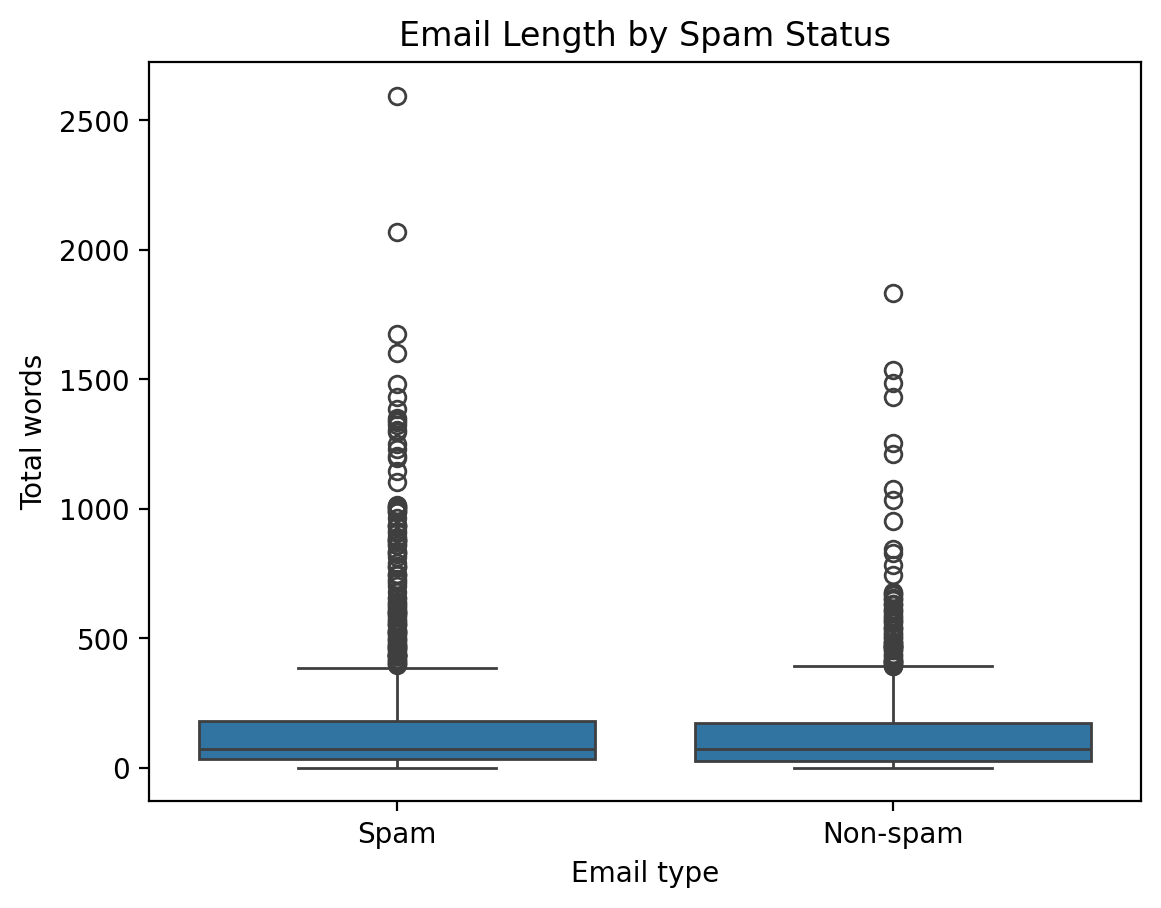

In [39]:
length_plot = pd.DataFrame({
    "Email type": ["Spam"] * len(spam_tf) + ["Non-spam"] * len(nonspam_tf),
    "Total words": list(spam_tf.sum(axis=1)) + list(nonspam_tf.sum(axis=1))
})

sns.boxplot(data=length_plot, x="Email type", y="Total words")
plt.title("Email Length by Spam Status")
plt.show()

In [33]:
# Question 2
print("Average unique words in spam:", (spam_tf > 0).sum(axis=1).mean())
print("Average unique words in non-spam:", (nonspam_tf > 0).sum(axis=1).mean())

Average unique words in spam: 110.10761421319798
Average unique words in non-spam: 73.78391959798995


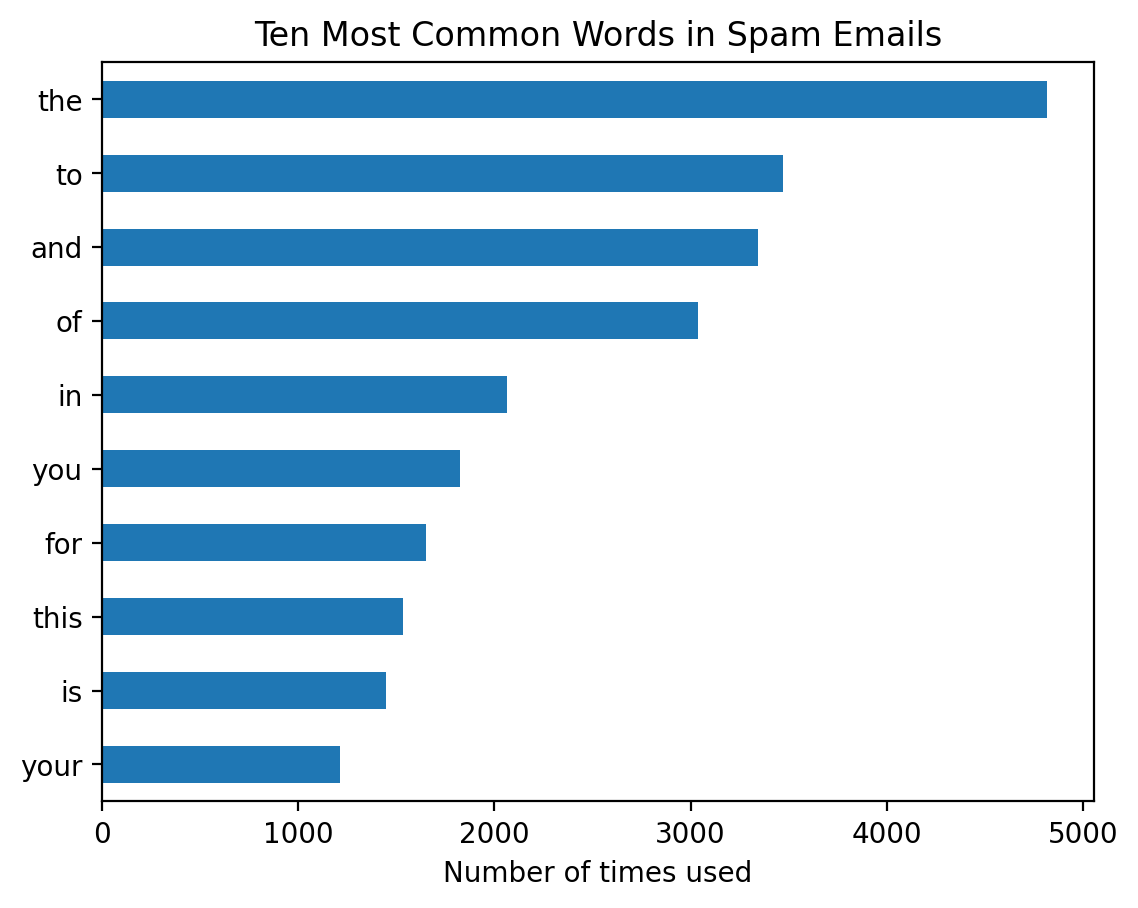

In [40]:
spam_tf.sum().nlargest(10).sort_values().plot.barh()
plt.xlabel("Number of times used")
plt.title("Ten Most Common Words in Spam Emails")
plt.show()

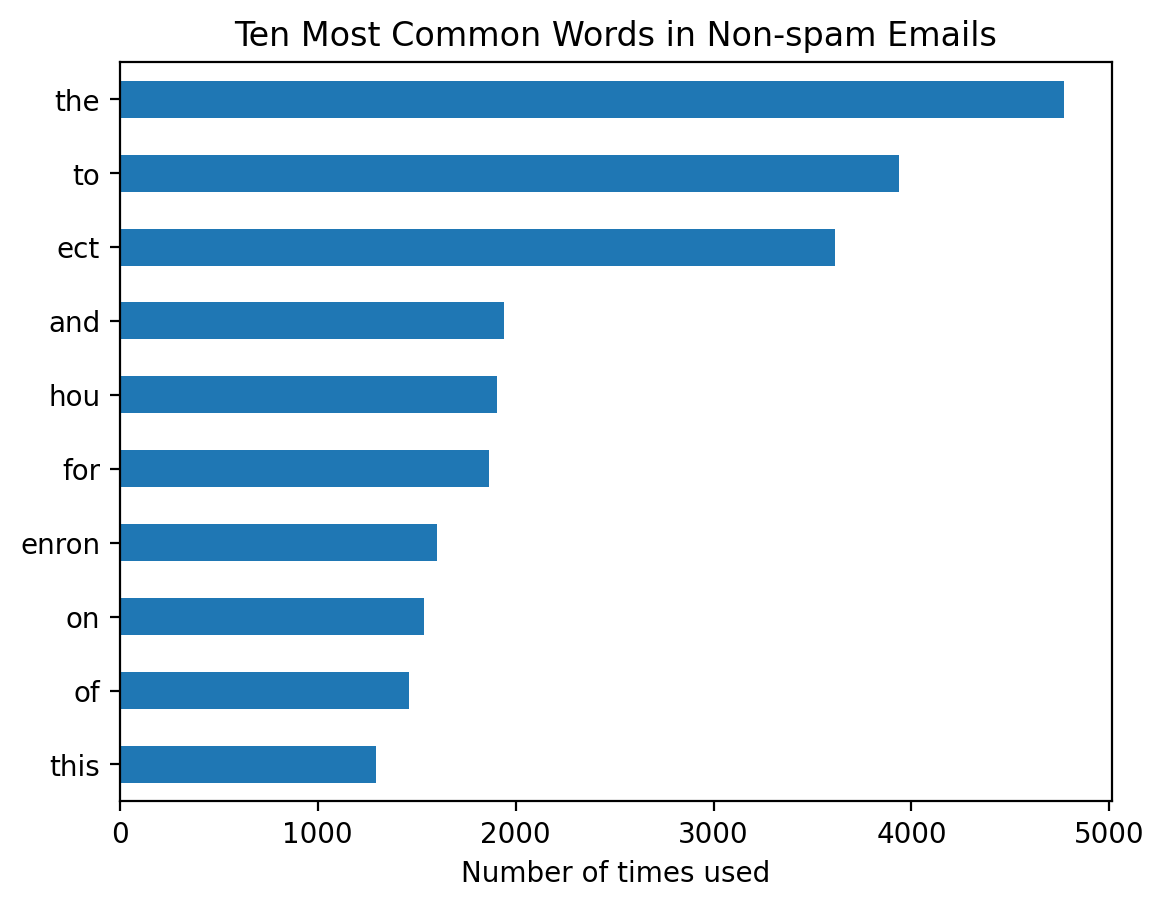

In [41]:
nonspam_tf.sum().nlargest(10).sort_values().plot.barh()
plt.xlabel("Number of times used")
plt.title("Ten Most Common Words in Non-spam Emails")
plt.show()

In [34]:
# Question 3
print("Spam:")
print(spam_tf.sum().sort_values(ascending=False).head(10))

print("\nNon-spam:")
print(nonspam_tf.sum().sort_values(ascending=False).head(10))

Spam:
the     4815
to      3472
and     3344
of      3038
in      2064
you     1827
for     1653
this    1536
is      1447
your    1215
dtype: int64

Non-spam:
the      4772
to       3939
ect      3616
and      1941
hou      1904
for      1866
enron    1601
on       1540
of       1461
this     1294
dtype: int64


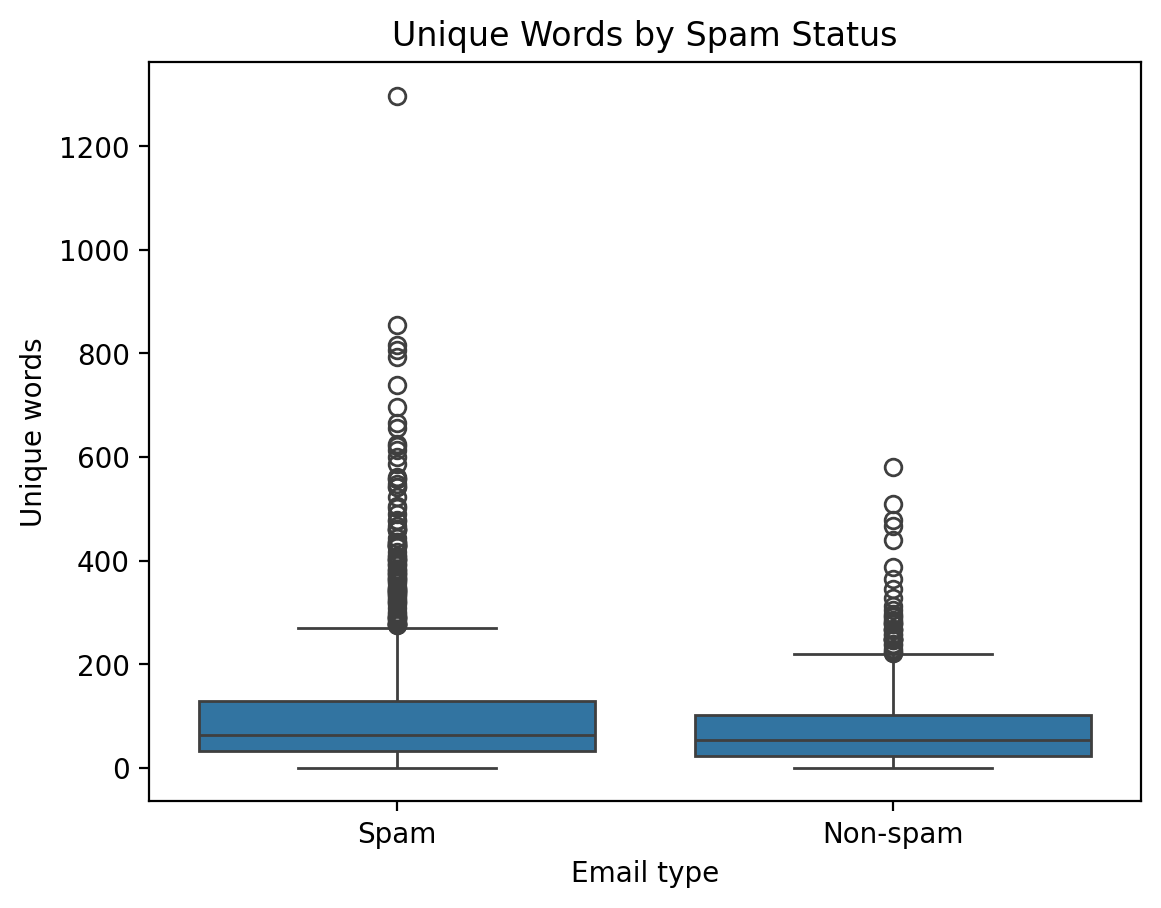

In [42]:
unique_plot = pd.DataFrame({
    "Email type": ["Spam"] * len(spam_tf) + ["Non-spam"] * len(nonspam_tf),
    "Unique words": (
        list((spam_tf > 0).sum(axis=1)) +
        list((nonspam_tf > 0).sum(axis=1))
    )
})

sns.boxplot(data=unique_plot, x="Email type", y="Unique words")
plt.title("Unique Words by Spam Status")
plt.show()

In [35]:
# Question 4
emails["spam"].value_counts().rename({
    0: "Non-spam",
    1: "Spam"
})

spam
Non-spam    995
Spam        985
Name: count, dtype: int64

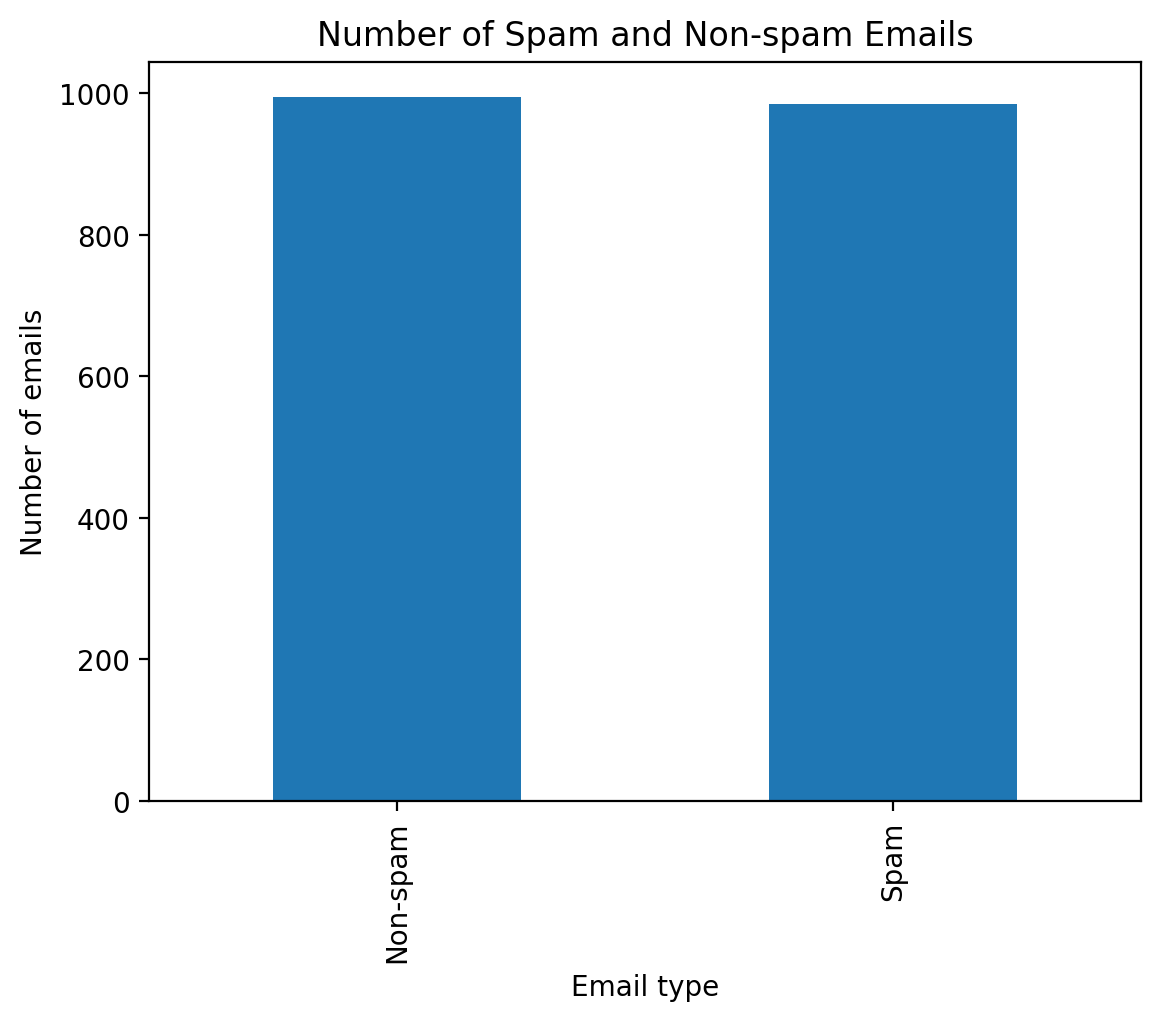

In [37]:
emails["spam"].value_counts().rename({
    0: "Non-spam",
    1: "Spam"
}).plot.bar()

plt.xlabel("Email type")
plt.ylabel("Number of emails")
plt.title("Number of Spam and Non-spam Emails")
plt.show()

7\. Now consider the 10 emails for which the true spam status is unknown. How might you decide if each email is spam or not? Brainstorm some ideas before proceeding. How can you use the TF and TF-IDF matrices for emails with known spam status?

**I would compare each unknown email’s TF or TF-IDF vector to the vectors for emails with known spam labels. If an unknown email is most similar to several known spam emails, I would classify it as spam; if it is most similar to non-spam emails, I would classify it as non-spam. Cosine distance is useful because it measures similarity based on the words used in the emails.**

8\. Consider just one email with unknown spam status, with `loc` 1980. Compute the cosine distance between the TF representation of this email and the TF representation of each of the emails with known spam status.

In [44]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
from sklearn.metrics.pairwise import cosine_distances

known_index = emails[emails["spam"].notna()].index

unknown_tf = tf[1980]

known_tf = tf[known_index]

distances = cosine_distances(unknown_tf, known_tf).flatten()

distance_results = pd.DataFrame({
    "spam": emails.loc[known_index, "spam"],
    "cosine_distance": distances
})

distance_results.head()

,spam,cosine_distance
0,0.0,0.736928
1,0.0,0.542990
2,0.0,0.775802
3,0.0,0.653954
4,0.0,0.519088


9\. Sort the results of the previous part to examine the emails with known spam status that are most similar to the unknown email. If you had to determine if the unknown email was spam or not, which would you pick and why?

In [45]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
distance_results.sort_values("cosine_distance").head(10)

,spam,cosine_distance
1889,1.0,0.393060
1032,1.0,0.398488
1376,1.0,0.408606
714,0.0,0.414644
1110,1.0,0.415807
26,0.0,0.418573
180,0.0,0.423172
879,0.0,0.424620
713,0.0,0.427930
139,0.0,0.434841


10\. Repeat the two previous parts using TF-IDF instead of TF. Do the results change?

In [46]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS

known_index = emails[emails["spam"].notna()].index

unknown_tfidf = tfidf[1980]

known_tfidf = tfidf[known_index]

tfidf_distances = cosine_distances(
    unknown_tfidf,
    known_tfidf
).flatten()

tfidf_distance_results = pd.DataFrame({
    "spam": emails.loc[known_index, "spam"],
    "cosine_distance": tfidf_distances
})

tfidf_distance_results.sort_values("cosine_distance").head(10)

,spam,cosine_distance
1032,1.0,0.755245
1977,1.0,0.780917
48,0.0,0.787975
1689,1.0,0.790205
1796,1.0,0.795094
180,0.0,0.797415
586,0.0,0.798537
1376,1.0,0.799377
279,0.0,0.799969
1021,1.0,0.801259


The TF-IDF results show that the ten emails most similar to email 1980 include six spam emails and four non-spam emails. The two closest emails are both spam, so I would classify email 1980 as spam. The exact cosine distances and ordering changed when using TF-IDF because it gives more weight to distinctive words and less weight to words that occur frequently across many emails.

11\. Now proceed in a similar manner to "guess" the spam status of each of the unknown emails.

In [47]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS

unknown_index = emails[emails["spam"].isna()].index
known_index = emails[emails["spam"].notna()].index

predictions = []

for i in unknown_index:
    
    d = cosine_distances(tfidf[i], tfidf[known_index]).flatten()
    
    closest_position = d.argmin()
    closest_index = known_index[closest_position]
    
    predictions.append({
        "unknown_email": i,
        "closest_known_email": closest_index,
        "cosine_distance": d[closest_position],
        "predicted_spam": emails.loc[closest_index, "spam"]
    })

predictions_df = pd.DataFrame(predictions)

predictions_df

,unknown_email,closest_known_email,cosine_distance,predicted_spam
0,1980,1032,0.755245,1.0
1,1981,836,0.687836,0.0
2,1982,718,0.614962,0.0
3,1983,579,0.504036,0.0
4,1984,380,0.389829,0.0
5,1985,1028,0.371277,1.0
6,1986,1141,0.768513,1.0
7,1987,1976,0.811616,1.0
8,1988,1121,0.748163,1.0
9,1989,245,0.856053,0.0
